In [4]:
import pandas as pd
from pathlib import Path


def species_distribution_statistic(
    scenario: str,
    data_dir: str = "../1_clean",
    out_dir: str = "output",
):

    # ======================
    # 1. Load data
    # ======================
    data_files = {
        "all": "data_merge_all_20260110.xlsx",
        "china": "data_merge_china.xlsx",
    }

    df = pd.read_excel(Path(data_dir) / data_files[scenario])
    df = df[~(df['host_species'].isna() & df['standard virus name'].isna())].reset_index(drop=True) #key
    print(df.shape[0])
    
    # ======================
    # 2. Basic cleaning
    # ======================
    df = (
        df[df["host_species"].notna()]
        .assign(
            host_species=lambda x: x["host_species"].str.strip(),
            gb=lambda x: x["gb"].astype(str),
        )
        .drop_duplicates(subset=["host_species", "gb"])  # ⭐ 关键：物种 × 县 去重
    )

    # ======================
    # 3. Species-level county counts
    # ======================
    species_county = (
        df.groupby("host_species", as_index=False)
        .size()
        .rename(columns={"size": "county_count"})
        .sort_values("county_count", ascending=False)
    )

    # ======================
    # 4. County × species presence matrix
    # ======================
    county_species_matrix = (
        df.assign(presence=1)
        .pivot(
            index="gb",
            columns="host_species",
            values="presence",
        )
        .fillna(0)
        .reset_index()
    )

    # ======================
    # 5. Save outputs
    # ======================
    out_path = Path(out_dir) / f"scenario={scenario}"
    out_path.mkdir(parents=True, exist_ok=True)

    species_county.to_excel(
        out_path / f"{scenario}_species_county_count.xlsx",
        index=False
    )

    county_species_matrix.to_excel(
        out_path / f"{scenario}_county_species_matrix.xlsx",
        index=False
    )

    print(
        f"[INFO] scenario={scenario} | "
        f"{species_county.shape[0]} species | "
        f"{county_species_matrix.shape[0]} counties"
    )


# ======================
# Run all scenarios
# ======================
species_distribution_statistic(scenario='all')

47196
[INFO] scenario=all | 291 species | 2175 counties


In [5]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

def map_county_to_grids(grid_map: gpd.GeoDataFrame,
                        county_map: gpd.GeoDataFrame) -> dict:
    mapping = {}

    for _, row in county_map.iterrows():
        gb = row["gb"]
        geom = row.geometry

        grids = grid_map.loc[
            grid_map.intersects(geom) | grid_map.contains(geom),
            "grid_index"
        ].unique()

        if len(grids) > 0:
            mapping[gb] = list(grids)

    return mapping

def build_grid_species_matrix(
    scenario: str,
    cell_size: float,
    county_map_path: str = "../0_map/中国_县_202509_GS(2024)0650.geojson",
    out_dir: str = "output"):

    # ======================
    # 1. Load data
    # ======================
    county_species = pd.read_excel(
        f"{out_dir}/scenario={scenario}/{scenario}_county_species_matrix.xlsx"
    )

    grid_map = gpd.read_file(
        f"{out_dir}/scenario={scenario}/cell={int(cell_size/1e3)}km/"
        f"{scenario}_{int(cell_size/1e3)}km_grid_map.geojson"
    )

    county_map = gpd.read_file(county_map_path)
    county_map["gb"] = county_map["gb"].astype(str)

    # ======================
    # 2. County → grid mapping
    # ======================
    county_grid_map = map_county_to_grids(grid_map, county_map)

    # ======================
    # 3. Species → grid distribution
    # ======================
    species_grids = {}

    for species in county_species.columns[1:]:
        counties = county_species.loc[
            county_species[species] > 0, "gb"
        ].astype(str)

        grids = set()
        for gb in counties:
            grids.update(county_grid_map.get(gb, []))

        if grids:
            species_grids[species] = sorted(grids)

    # ======================
    # 4. Build grid × species presence matrix
    # ======================
    all_grids = grid_map["grid_index"].unique()
    presence_df = pd.DataFrame({"grid_index": all_grids})

    species_columns = {
        species: presence_df["grid_index"].isin(grids).astype(int)
        for species, grids in species_grids.items()
    }

    presence_df = pd.concat(
        [presence_df, pd.DataFrame(species_columns)],
        axis=1
    )

    # ======================
    # 5. Filter empty grids & species
    # ======================
    presence_df["species_count"] = presence_df.drop("grid_index", axis=1).sum(axis=1)
    final_df = (
        presence_df[presence_df["species_count"] >= 1]
        .drop(columns="species_count")
        .reset_index(drop=True)
    )

    # ======================
    # 6. Save
    # ======================
    out_path = (
        Path(out_dir)
        / f"scenario={scenario}"
        / f"cell={int(cell_size/1e3)}km"
    )
    out_path.mkdir(parents=True, exist_ok=True)

    final_df.to_excel(
        out_path / f"{scenario}_{int(cell_size/1e3)}km_grid_species_matrix.xlsx",
        index=False
    )

    print(
        f"[INFO] grid cells: {final_df.shape[0]} | "
        f"species: {final_df.shape[1] - 1}"
    )

build_grid_species_matrix(
    scenario='all',
    cell_size=40000)

[INFO] grid cells: 5869 | species: 291


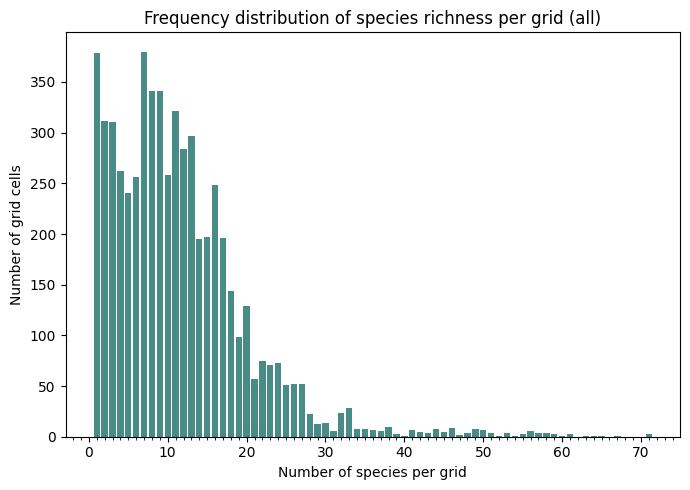

[INFO] Histogram saved to: output/scenario=all/cell=40km/all_grid_species_richness_histogram_20260110.tif


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as mticker
from datetime import datetime

def plot_grid_species_richness(
    scenario: str,
    input_dir: str,
    grid_species_file: str):

    
    # ===============================
    # 1. 读取数据
    # ===============================
    input_path = Path(input_dir) / grid_species_file
    df = pd.read_excel(input_path)
    
    # ===============================
    # 2. 统计每个栅格的物种数
    # ===============================
    species_count_per_grid = df.drop(columns="grid_index").sum(axis=1)
    grid_richness_df = pd.DataFrame({
        "grid_index": df["grid_index"],
        "species_count": species_count_per_grid
    })
    
    # ===============================
    # 3. 统计频率分布
    # ===============================
    richness_frequency = grid_richness_df["species_count"].value_counts().sort_index()
    
    # ===============================
    # 4. 绘制频率直方图
    # ===============================
    plt.figure(figsize=(7, 5))
    plt.bar(richness_frequency.index, richness_frequency.values, color="#488B87", width=0.8)
    plt.xlabel("Number of species per grid")
    plt.ylabel("Number of grid cells")
    plt.title(f"Frequency distribution of species richness per grid ({scenario})")
    plt.xticks(richness_frequency.index)
    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10))
    plt.gca().xaxis.set_minor_locator(mticker.MultipleLocator(1))
    plt.tight_layout()

    # ===============================
    # 5. 保存图像
    # ===============================
    date_str = datetime.now().strftime("%Y%m%d")  # 例如 20260107
    save_file = f"output/scenario={scenario}/cell=40km/{scenario}_grid_species_richness_histogram_{date_str}.tif"
    plt.savefig(save_file, dpi=300)
    plt.show()
    print(f"[INFO] Histogram saved to: {save_file}")

plot_grid_species_richness(
    scenario="all",
    input_dir="output/scenario=all/cell=40km",
    grid_species_file="all_40km_grid_species_matrix.xlsx"
)
